In [ ]:
import csv
import os
import sys
import pandas as pd
import numpy as np
from sklearn.preprocessing import RobustScaler
from emmaemb.core import Emma
sys.path.append('/home/unix/vkrhk/EmmaEmb/analysis')

IMG_OUTPUT_PATH = '/home/unix/vkrhk/EmmaEmb/img'
DATA_PATH = '/home/unix/vkrhk/EmmaEmb/data'
EMBEDDINGS_PATH = '/media/drive2/vkrhk/embeddings'
SUBSET_SIZE = 1000 # take first N proteins from each dataset for testing

# Amino acid classification dictionary
amino_acid_classification = {
    'V': 'hydrophobic', # Valine
    'L': 'hydrophobic', # Leucine
    'I': 'hydrophobic', # Isoleucine
    'M': 'hydrophobic', # Methionine
    'F': 'hydrophobic', # Phenylalanine
    'W': 'tryptophan', # Tryptophan
    'P': 'proline', # Proline
    'S': 'polar uncharged', # Serine
    'T': 'polar uncharged', # Threonine
    'C': 'Cytosine', # Cysteine
    'Y': 'Tyrosine', # Tyrosine
    'N': 'polar uncharged', # Asparagine
    'Q': 'polar uncharged', # Glutamine
    'D': 'charged', # Aspartate
    'E': 'charged', # Glutamate
    'K': 'charged', # Lysine
    'R': 'charged', # Arginine
    'A': 'Alanine', # Alanine
    'H': 'Histidine', # Histidine
    'G': 'Glycine', # Glycine
    'X': 'Unknown', # Unknown
    'U': 'Selenocysteine' # Selenocysteine
}

max_sasa_values = {
    'A': 121.0,  # Alanine
    'R': 265.0,  # Arginine
    'N': 187.0,  # Asparagine
    'D': 187.0,  # Aspartate
    'C': 148.0,  # Cysteine
    'E': 214.0,  # Glutamate
    'Q': 214.0,  # Glutamine
    'G': 97.0,   # Glycine
    'H': 216.0,  # Histidine
    'I': 195.0,  # Isoleucine
    'L': 191.0,  # Leucine
    'K': 230.0,  # Lysine
    'M': 203.0,  # Methionine
    'F': 228.0,  # Phenylalanine
    'P': 154.0,  # Proline
    'S': 143.0,  # Serine
    'T': 163.0,  # Threonine
    'W': 264.0,  # Tryptophan
    'Y': 255.0,  # Tyrosine
    'V': 165.0,   # Valine
    'X': 200.0,  # Unknown, set to a good-enough value
    'U': 200.0   # Selenocysteine
}

# [embeddings_name, embeddings_path] = "ESM1", f"{EMBEDDINGS_PATH}/esm1_t34_670M_UR100/layer_34/chopped_1022_overlap_300/"
[embeddings_name, embeddings_path] = "ESM2", f"{EMBEDDINGS_PATH}/esm2_t33_650M_UR50D/layer_33/chopped_1022_overlap_300"

concatenated_embeddings_path = f"{DATA_PATH}/concatenated-embeddings/{embeddings_name}_binding_site_embeddings.npy"

feature_data = []
embeddings = []

# train RobustScaler on the SASA values from the training set:
sasa_values = []
for sasa_file in os.listdir(f"{DATA_PATH}/sasa_per_residue"):
    sasa = np.load(f"{DATA_PATH}/sasa_per_residue/{sasa_file}")
    sasa_values.extend(sasa)
sasa_values = np.array(sasa_values)
sasa_scaler = RobustScaler()
sasa_scaler.fit(sasa_values.reshape(-1, 1))


for dataset in ['train.txt', 'scPDB_enhanced_binding_sites_translated.csv']:
    with open(f'{DATA_PATH}/{dataset}', 'r') as f:
        reader = csv.reader(f, delimiter=';')
        for ii, row in enumerate(reader):
            protein_id = row[0] + row[1]
            annotation = row[3].split(' ')
            annotation = [int(i[1:]) for i in annotation]
            sequence = row[4]
            path = f"{embeddings_path}/{protein_id}.npy"

            if not os.path.exists(path):
                continue
            
            embedding = np.load(path)
            sasa = np.load(f"{DATA_PATH}/sasa_per_residue/{protein_id}.npy")
            # sasa = sasa_scaler.transform(sasa.reshape(-1, 1)).flatten()
                                    
            if embedding.shape[0] != len(sasa):
                print(f"Skipping {protein_id} due to shape mismatch.")
                continue

            BINDING_FLAG = 'CRYPTIC-BINDING' if dataset == 'train.txt' else 'BINDING'
            for i in range(len(sequence)):
                feature_data.append([f'{protein_id}_{i}', sequence[i], BINDING_FLAG if i in annotation else 'NON-BINDING', float(sasa[i]), float(sasa[i]) / max_sasa_values[sequence[i]], protein_id, amino_acid_classification[sequence[i]]])
            embeddings.append(embedding)
            # print(sasa)
            if ii >= SUBSET_SIZE:
                break

embeddings =  np.concatenate(embeddings, axis=0)
np.save(concatenated_embeddings_path, embeddings)  

feature_data = pd.DataFrame.from_records(feature_data, columns=["ID", "amino_acid", "binding_site", "sasa", "normalized_sasa", "protein_id", "amino_acid_type"])
feature_data['normalized_sasa'] = feature_data['normalized_sasa'].astype(float) / feature_data['normalized_sasa'].astype(float).max() # map to [0, 1]
feature_data['normalized_sasa'] = feature_data['normalized_sasa'].clip(0, 0.5) # cap normalized SASA values at 0.5 to prevent outliers from dominating the color scale
# initiate Emma object and load embedding spaces
emma = Emma(feature_data=feature_data)
emma.add_emb_space(
    embeddings_source=concatenated_embeddings_path,
    emb_space_name=embeddings_name)


Skipping protein_id as it has more than                         50 unique values.
30372 samples loaded.
Categories in meta data: ['amino_acid', 'binding_site', 'protein_id', 'amino_acid_type']
Numerical columns in meta data: ['sasa', 'normalized_sasa']
Embedding space 'ESM2' added successfully.
Embeddings have 1280 features each.


In [ ]:
from emmaemb.vizualisation import (
    plot_emb_space,
    plot_knn_alignment_scores_across_k_and_distance_metrics,
    plot_pairwise_distance_comparison
)
import plotly as px
fig_1 = plot_emb_space(emma, emb_space="ESM1", color_by="normalized_sasa", method="PCA")
fig_1.update_traces(marker={'size': 2}, opacity=.3)
fig_1.update_layout(coloraxis={"colorscale": px.colors.sequential.RdBu})
fig_1.update_layout(height=600, width=800)
fig_1.show()

# Note
This means there is separation between surface & buried residues.

In [ ]:
from emmaemb.vizualisation import (
    plot_emb_space,
    plot_knn_alignment_scores_across_k_and_distance_metrics,
    plot_pairwise_distance_comparison
)
fig_1 = plot_emb_space(emma, emb_space="ESM1", color_by="protein_id", method="PCA")
fig_1.update_traces(marker={'size': 5})
fig_1.update_layout(height=600, width=800)
fig_1.show()

In [ ]:
from emmaemb.vizualisation import (
    plot_emb_space,
    plot_knn_alignment_scores_across_k_and_distance_metrics,
    plot_pairwise_distance_comparison
)
fig_1 = plot_emb_space(emma, emb_space="ESM1", color_by="amino_acid", method="PCA")
fig_1.update_traces(marker={'size': 2}, opacity=.3)
fig_1.update_layout(legend=dict(itemsizing='constant'))
fig_1.update_layout(height=600, width=800)
fig_1.show()

In [ ]:
from emmaemb.vizualisation import (
    plot_emb_space,
    plot_knn_alignment_scores_across_k_and_distance_metrics,
    plot_pairwise_distance_comparison
)
fig_1 = plot_emb_space(emma, emb_space="ESM1", color_by="amino_acid_type", method="PCA")
fig_1.update_traces(marker={'size': 2}, opacity=.3)
fig_1.update_layout(legend=dict(itemsizing='constant'), legend_x=0, legend_y=1)
fig_1.update_layout(height=600, width=800)
fig_1.show()

In [6]:
from emmaemb.vizualisation import (
    plot_emb_space,
    plot_knn_alignment_scores_across_k_and_distance_metrics,
    plot_pairwise_distance_comparison
)
# fig_1 = plot_emb_space(emma, emb_space="ESM1", color_by="binding_site", method="PCA")
fig_1 = plot_emb_space(emma, emb_space="ESM2", color_by="binding_site", method="PCA")
fig_1.update_traces(marker={'size': 4}, opacity=.3)
fig_1.update_layout(legend=dict(itemsizing='constant'), legend_x=0, legend_y=1)
fig_1.update_layout(height=600, width=800)
fig_1.show()

In [2]:
from emmaemb.vizualisation import (
    plot_emb_space,
    plot_knn_alignment_scores_across_k_and_distance_metrics,
    plot_pairwise_distance_comparison
)
fig_1 = plot_emb_space(emma, emb_space="ESM1", color_by="binding_site", method="UMAP", random_state=None)
fig_1.update_traces(marker={'size': 4}, opacity=.3)
fig_1.update_layout(legend=dict(itemsizing='constant'), legend_x=0, legend_y=1)
fig_1.update_layout(height=600, width=800)
fig_1.show()

## Ideas
1. Try finetuned embeddings (cryptic vs. regular)
    - generate embeddings from cryptic-finetuned pLM on cryptic vs. regular binding sites
    - generate embeddings from regular-finetuned pLM on cryptic vs. regular binding sites

2. PCA for 100 PCs was running and trying to find best pair - check the results

In [4]:
from emmaemb.vizualisation import plot_knn_alignment_across_classes

emma.calculate_pairwise_distances(emb_space=embeddings_name, metric='euclidean')

fig_3 = plot_knn_alignment_across_classes(
    emma, k=3, metric='euclidean', feature='binding_site')
fig_3.update_layout(height=400, width=700)
fig_3.show()


Calculating pairwise distances using euclidean...
Using GPU for distance calculation.


Computing pairwise distances (euclidean): 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████| 304/304 [00:02<00:00, 131.06it/s]


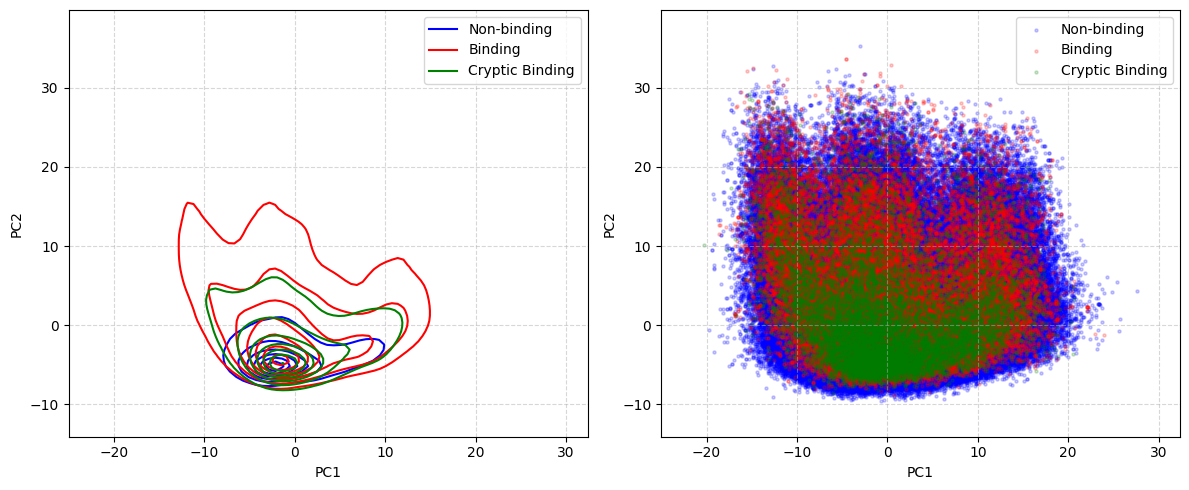

In [ ]:
from dim_reduction_utils import plot_scatter, prepare_data

reduction_algorithm = "PCA"
n_components = 2
embeddings_2d = emma.get_2d(emb_space="ESM1", method=reduction_algorithm)
_, labels = prepare_data(emma, embeddings_name)
plot_scatter(embeddings_2d['2d'], labels, x_idx=0, y_idx=1, emb_space=embeddings_name, method=reduction_algorithm, \
    path=f'{IMG_OUTPUT_PATH}/tweaked,plot0:{reduction_algorithm},n_components={n_components},best,N={SUBSET_SIZE}/{embeddings_name}_{reduction_algorithm}_best_pair.png')